# K-Nearest Neighbors (K-NN) — Classification (Google Colab)

**Goal:** Predict a **binary class** (0/1) using **K-Nearest Neighbors** — a **lazy**, **distance-based** classifier that votes among the **K closest** training points.

| Example | Feature(s) (X) | Target (y) | Dataset |
|---------|----------------|------------|---------|
| **Example 1** | Age, EstimatedSalary | Purchased (0/1) | `../Datasets/social_network_ads.csv` |
| **Example 2** | CreditScore, Income, LoanAmount, YearsEmployed | Approved (0/1) | `../Datasets/loan_approval.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| — | Algorithm Guide | Distance, K, voting, choosing K |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

---
# Algorithm Guide — K-Nearest Neighbors (K-NN)

## What is K-NN?

**K-NN** classifies a new point by looking at the **K nearest neighbors** in the training data and taking a **majority vote**.

| Property | Detail |
|----------|--------|
| Type | **Lazy learner** — no explicit training phase |
| Decision rule | **Majority vote** among K closest points |
| Distance | Usually **Euclidean** distance |
| Output | Class label (+ optional probability from neighbor votes) |

## How K-NN Works (Step by Step)

| Step | Action |
|------|--------|
| 1 | Store all training data (no model coefficients learned) |
| 2 | For a new point **x**, compute distance to **every** training point |
| 3 | Select the **K** points with smallest distance |
| 4 | **Vote:** predict the most common class among those K neighbors |
| 5 | (Tie-break) Use weighted vote by distance if `weights='distance'` |

## Euclidean Distance (2 features)

`d = √[(x₁ − x₁')² + (x₂ − x₂')²]`

Features with **larger scale** dominate distance → **StandardScaler is required**.

## Choosing K

| K value | Effect |
|---------|--------|
| **K = 1** | Very flexible — sensitive to noise (**overfitting**) |
| **Small K** | Complex decision boundary |
| **Large K** | Smoother boundary — may **underfit** |
| **Even K** | Possible ties — prefer **odd K** (e.g. 3, 5, 7) |

Use **cross-validation** to pick K that maximizes validation accuracy.

## Key Hyperparameters (sklearn)

| Parameter | Role |
|-----------|------|
| `n_neighbors` | **K** — number of neighbors |
| `metric` | Distance measure (`'euclidean'`, `'manhattan'`, ...) |
| `weights` | `'uniform'` (equal vote) or `'distance'` (closer = more weight) |
| `n_jobs` | Parallel distance computation (`-1` = all cores) |

## K-NN vs Logistic Regression

| | Logistic Regression | K-NN |
|---|---------------------|------|
| Training | Learns coefficients | **Stores** all data |
| Boundary | Linear (log-odds) | **Non-linear**, flexible |
| Scaling | Recommended | **Required** |
| Speed (predict) | Fast | Slower — scans all training points |
| Interpretability | Coefficients | Harder — depends on neighbors |

## What the Student Must Remember

1. K-NN = **majority vote** of **K nearest** training points.
2. **Always scale features** before K-NN (distance-based).
3. **Choose K** carefully — use cross-validation.
4. **Odd K** avoids tie votes in binary classification.
5. K-NN is a **lazy learner** — "training" just stores the dataset.

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [1]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for preprocessing, K-NN classification, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, sklearn KNeighborsClassifier, and metrics.

In [2]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots

from sklearn.model_selection import train_test_split, cross_val_score  # Split & cross-validation
from sklearn.impute import SimpleImputer                   # Fill missing values
from sklearn.preprocessing import StandardScaler           # Feature scaling (required for K-NN)
from sklearn.pipeline import Pipeline                      # Chain scaler + classifier
from sklearn.neighbors import KNeighborsClassifier         # K-Nearest Neighbors classifier
from sklearn.metrics import (                              # Classification metrics
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Example 1: Social Network Ads — K-NN Classification

Predict whether a user **Purchased** from **Age** and **EstimatedSalary** using K-NN.

| Column | Role | Description |
|--------|------|-------------|
| `Age` | Feature (X₁) | User age in years |
| `EstimatedSalary` | Feature (X₂) | Estimated annual salary in USD |
| `Purchased` | Target (y) | 0 = No, 1 = Yes |

**File:** `../Datasets/social_network_ads.csv`

---
# Phase 1: Data Pre-processing

Prepare the data before training — same template is reused for other algorithms.

## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/social_network_ads.csv` and displays basic statistics.

In [3]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/social_network_ads.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['Age', 'EstimatedSalary']  # Two numeric input features
TARGET_COL = 'Purchased'                    # Binary target: 0 = No, 1 = Yes

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nClass balance ({TARGET_COL}):')
print(dataset[TARGET_COL].value_counts())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,Age,EstimatedSalary,Purchased
0,56,115235,1
1,46,89740,1
2,32,131352,1
3,60,81617,0
4,25,31896,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB

Statistical summary:


,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,39.605000,80844.840000,0.420000
std,12.374846,39484.169884,0.494177
min,18.000000,15404.000000,0.000000
25%,29.000000,42699.750000,0.000000
50%,41.000000,81218.500000,0.000000
75%,50.000000,117134.250000,1.000000
max,60.000000,149668.000000,1.000000



Class balance (Purchased):
Purchased
0    232
1    168
Name: count, dtype: int64

Shape: 400 rows x 3 columns


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values, remove duplicates, and apply imputation if needed.

**What this cell does:** Cleans the dataset before modeling.

In [4]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
rows_after = len(dataset)
print(f'\nDuplicates removed: {rows_before - rows_after}')

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
if dataset.isnull().sum().sum() > 0:
    dataset[num_cols] = imputer.fit_transform(dataset[num_cols])
    print('Missing values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {rows_after}')

Missing values per column:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 400


## Example 1 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [5]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')
    print(f'Target column: {TARGET_COL} (already 0/1)')

No categorical columns — encoding skipped.
Feature columns: ['Age', 'EstimatedSalary']
Target column: Purchased (already 0/1)


## Example 1 — Cell 4: Splitting the Data

Define X and y, then split 80/20 with **stratify** to preserve class ratio.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [6]:
# Step 4) Train-Test split (stratified for classification)

X = dataset[FEATURE_COLS].values  # Feature matrix: Age and EstimatedSalary
y = dataset[TARGET_COL].values    # Target vector: Purchased (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train class counts: {np.bincount(y_train)}')
print(f'y_test class counts:  {np.bincount(y_test)}')

X_train shape: (320, 2)
X_test shape:  (80, 2)
y_train class counts: [186 134]
y_test class counts:  [46 34]


> **Note:** K-NN uses **distance** — **StandardScaler is mandatory** so Age and Salary contribute fairly.

---
# Phase 2: K-NN — Social Network Ads

Choose **K** with cross-validation, then train and evaluate.

## Example 1 — Cell 5: Choose K and Train the Model

Try K = 1 to 20 with **5-fold cross-validation** on the training set, then train with the best K.

**What this cell does:** Selects optimal K and fits the K-NN pipeline.

Best K from cross-validation: 9
Best CV accuracy: 0.7812


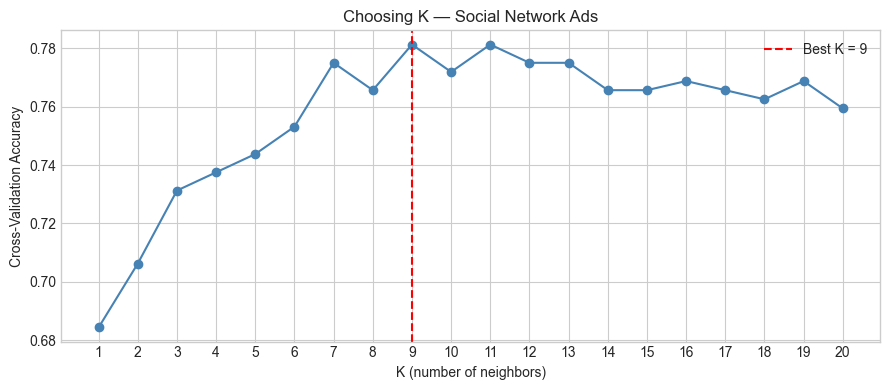


K-NN trained with K = 9 (lazy learner — stores 320 training points)


In [7]:
# Step 5) Choose K with cross-validation, then train K-NN

K_range = range(1, 21)           # Test K from 1 to 20
cv_scores = []                   # Store mean CV accuracy for each K

for k in K_range:
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),                    # Scale features before distance calc
        ('model', KNeighborsClassifier(n_neighbors=k))   # K-NN with K neighbors
    ])
    scores = cross_val_score(knn_pipe, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold CV
    cv_scores.append(scores.mean())  # Average accuracy across folds

best_k = list(K_range)[np.argmax(cv_scores)]  # K with highest CV accuracy
print(f'Best K from cross-validation: {best_k}')
print(f'Best CV accuracy: {max(cv_scores):.4f}')

# Plot K vs accuracy
plt.figure(figsize=(9, 4))
plt.plot(list(K_range), cv_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Choosing K — Social Network Ads')
plt.xticks(list(K_range))
plt.legend()
plt.tight_layout()
plt.show()

# Train final model with best K
classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1))
])
classifier.fit(X_train, y_train)  # Store scaled training data for neighbor lookup

print(f'\nK-NN trained with K = {best_k} (lazy learner — stores {len(X_train)} training points)')

## Example 1 — Cell 6: Predict

Predict class labels on the test set. K-NN can also output probabilities from neighbor votes.

**What this cell does:** Uses `predict()` and `predict_proba()` on test data.

In [8]:
# Step 6) Predict classes and probabilities

y_pred_train = classifier.predict(X_train)            # Class labels for training set
y_pred_test = classifier.predict(X_test)              # Class labels for test set
y_proba_test = classifier.predict_proba(X_test)[:, 1]  # Fraction of K neighbors that voted class 1

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    label = 'Yes' if y_pred_test[i] == 1 else 'No'
    actual = 'Yes' if y_test[i] == 1 else 'No'
    print(f'  Actual={actual}, Predicted={label}, Neighbor vote P(Yes)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=No, Predicted=No, Neighbor vote P(Yes)=22.22%
  Actual=Yes, Predicted=Yes, Neighbor vote P(Yes)=88.89%
  Actual=Yes, Predicted=No, Neighbor vote P(Yes)=33.33%
  Actual=No, Predicted=No, Neighbor vote P(Yes)=0.00%
  Actual=No, Predicted=No, Neighbor vote P(Yes)=0.00%


## Example 1 — Cell 7: Visualization

Plot training points and the **K-NN decision boundary** (non-linear regions).

**What this cell does:** Shows how K-NN partitions the Age–Salary plane.

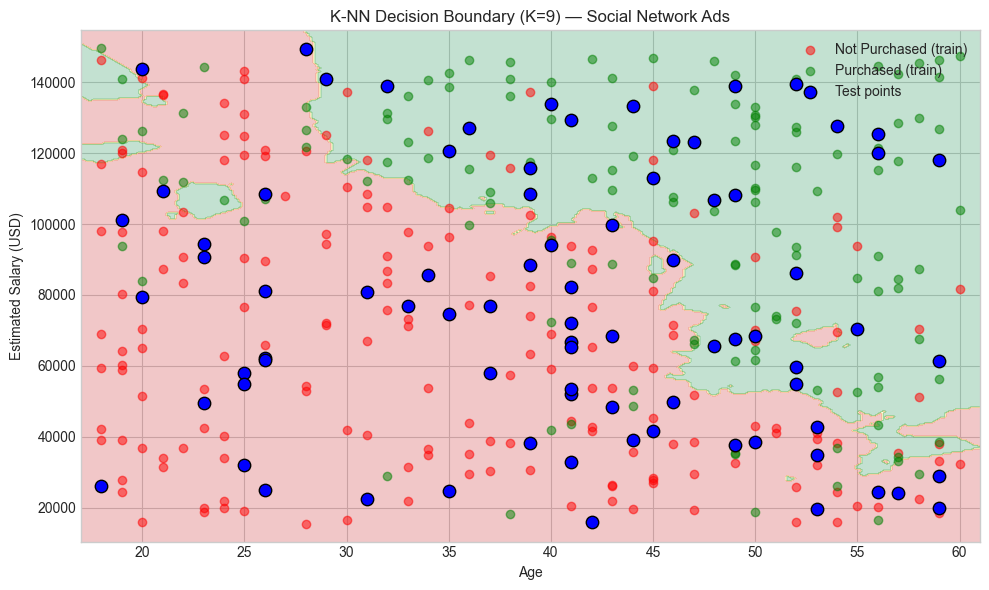

In [9]:
# Step 7) Visualization — scatter + K-NN decision boundary

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 5000, X[:, 1].max() + 5000
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = classifier.predict(grid).reshape(xx.shape)  # Predicted class at each grid point

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')  # Decision regions
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', label='Not Purchased (train)', alpha=0.5)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='green', label='Purchased (train)', alpha=0.5)
plt.scatter(X_test[:, 0], X_test[:, 1], c='blue', edgecolors='k', s=80, label='Test points')
plt.xlabel('Age')
plt.ylabel('Estimated Salary (USD)')
plt.title(f'K-NN Decision Boundary (K={best_k}) — Social Network Ads')
plt.legend()
plt.tight_layout()
plt.show()

## Example 1 — Cell 8: Evaluation

Evaluate with Accuracy, Precision, Recall, F1, and Confusion Matrix.

**What this cell does:** Computes classification metrics on the test set.

,Metric,Value,Description
0,Accuracy,0.7875,Fraction of correct predictions
1,Precision,0.7931,"Of predicted Yes, fraction actually Yes"
2,Recall,0.6765,"Of actual Yes, fraction correctly predicted"
3,F1 Score,0.7302,Balance between Precision and Recall



Confusion Matrix (rows=Actual, cols=Predicted):
[[40  6]
 [11 23]]


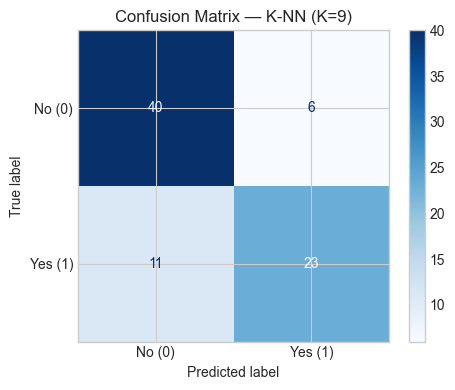


Example 1 Test Accuracy = 0.7875


In [10]:
# Step 8) Evaluation — classification metrics

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Yes, fraction actually Yes',
        'Of actual Yes, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))

cm = confusion_matrix(y_test, y_pred_test)
print('\nConfusion Matrix (rows=Actual, cols=Predicted):')
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)']).plot(ax=ax, cmap='Blues')
plt.title(f'Confusion Matrix — K-NN (K={best_k})')
plt.tight_layout()
plt.show()

print(f'\nExample 1 Test Accuracy = {acc:.4f}')

## Why does K-NN work for Social Network Ads?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Non-linear boundary** | Purchase patterns need flexible regions — K-NN adapts locally |
| 2 | **Two features** | Easy to visualize neighbors in Age–Salary space |
| 3 | **Distance + scaling** | Salary range is large — StandardScaler makes Age and Salary comparable |
| 4 | **Choosing K** | Cross-validation prevents overfitting (K=1) and underfitting (K too large) |
| 5 | **No assumptions** | Unlike logistic regression, K-NN does not assume a linear boundary |

> **Summary:** Users similar in age and salary tend to share purchase behavior — K-NN finds them by distance.

## Understanding Classification Metrics — Example 1

| Metric | K-NN Context |
|--------|--------------|
| **Accuracy** | Overall correct votes |
| **Precision** | When K-NN predicts Yes, how often correct |
| **Recall** | Of all actual Yes, how many K-NN catches |
| **F1** | Balance when classes are imbalanced (~42% purchased) |

> **Tip:** Compare decision boundaries — K-NN vs Logistic Regression on the same dataset.

---
# Example 2: Loan Approval — K-NN Classification

Predict **Approved** vs **Rejected** from four financial features using K-NN.

| Column | Role | Description |
|--------|------|-------------|
| `CreditScore` | Feature (X₁) | Credit score (300–850) |
| `Income` | Feature (X₂) | Annual income in USD |
| `LoanAmount` | Feature (X₃) | Requested loan amount in USD |
| `YearsEmployed` | Feature (X₄) | Years at current job |
| `Approved` | Target (y) | 1 = Approved, 0 = Rejected |

**File:** `../Datasets/loan_approval.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the loan approval CSV and inspect the data.

**What this cell does:** Reads `../Datasets/loan_approval.csv` and displays basic statistics.

In [11]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/loan_approval.csv')

FEATURE_COLS = ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']
TARGET_COL = 'Approved'

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nClass balance ({TARGET_COL}):')
print(dataset[TARGET_COL].value_counts())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
0,452.0,87003,152038.0,4.2,0
1,785.0,108211,134862.0,5.1,1
2,698.0,77733,128834.0,6.6,1
3,620.0,90318,103848.0,19.9,1
4,456.0,134953,62921.0,14.2,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CreditScore    249 non-null    float64
 1   Income         250 non-null    int64  
 2   LoanAmount     249 non-null    float64
 3   YearsEmployed  250 non-null    float64
 4   Approved       250 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 9.9 KB

Statistical summary:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
count,249.000000,250.000000,249.000000,250.000000,250.000000
mean,585.995984,82134.284000,91971.630522,10.466800,0.500000
std,133.107085,34366.209563,49499.083375,5.456677,0.501003
min,351.000000,25301.000000,11062.000000,1.000000,0.000000
25%,480.000000,53138.000000,47841.000000,5.825000,0.000000
50%,583.000000,80214.000000,96900.000000,10.750000,0.500000
75%,695.000000,112522.500000,129180.000000,15.150000,1.000000
max,813.000000,137893.000000,178152.000000,19.900000,1.000000



Class balance (Approved):
Approved
0    125
1    125
Name: count, dtype: int64

Shape: 250 rows x 5 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

This dataset includes missing values in features to demonstrate `SimpleImputer`.

**What this cell does:** Checks for nulls, removes duplicates, and imputes missing values.

In [12]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
print(f'\nDuplicates removed: {rows_before - len(dataset)}')

if dataset[TARGET_COL].isnull().sum() > 0:
    dataset = dataset.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    print('Rows with missing target removed')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
cols = FEATURE_COLS + [TARGET_COL]
if dataset[cols].isnull().sum().sum() > 0:
    dataset[cols] = imputer.fit_transform(dataset[cols])
    print('Missing feature values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {len(dataset)}')

Missing values per column:
CreditScore      1
Income           0
LoanAmount       1
YearsEmployed    0
Approved         0
dtype: int64

Duplicates removed: 0
Missing feature values imputed with mean

Rows after cleaning: 250


## Example 2 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [13]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')

No categorical columns — encoding skipped.
Feature columns: ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']


## Example 2 — Cell 4: Splitting the Data

Define X (4 features) and y (Approved), then split 80/20 with stratify.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [14]:
# Step 4) Train-Test split

X = dataset[FEATURE_COLS].values
y = dataset[TARGET_COL].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train class counts: {np.bincount(y_train)}')
print(f'y_test class counts:  {np.bincount(y_test)}')

X_train shape: (200, 4)
X_test shape:  (50, 4)
y_train class counts: [100 100]
y_test class counts:  [25 25]


## Example 2 — Cell 5: Choose K and Train the Model

Select K via cross-validation on 4-dimensional scaled features.

**What this cell does:** Finds best K and fits K-NN on loan approval data.

In [15]:
# Step 5) Choose K and train K-NN

K_range = range(1, 21)
cv_scores = []

for k in K_range:
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_pipe, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = list(K_range)[np.argmax(cv_scores)]
print(f'Best K from cross-validation: {best_k}')
print(f'Best CV accuracy: {max(cv_scores):.4f}')

classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1))
])
classifier.fit(X_train, y_train)

print(f'K-NN trained with K = {best_k}')

Best K from cross-validation: 19
Best CV accuracy: 0.8450
K-NN trained with K = 19


## Example 2 — Cell 6: Predict

Predict loan approval on the test set.

**What this cell does:** Generates class predictions and neighbor-vote probabilities.

In [16]:
# Step 6) Predict

y_pred_test = classifier.predict(X_test)
y_proba_test = classifier.predict_proba(X_test)[:, 1]

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    actual = 'Approved' if y_test[i] == 1 else 'Rejected'
    pred = 'Approved' if y_pred_test[i] == 1 else 'Rejected'
    print(f'  Actual={actual}, Predicted={pred}, Neighbor vote P(Approved)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=Approved, Predicted=Approved, Neighbor vote P(Approved)=73.68%
  Actual=Rejected, Predicted=Rejected, Neighbor vote P(Approved)=5.26%
  Actual=Rejected, Predicted=Rejected, Neighbor vote P(Approved)=5.26%
  Actual=Rejected, Predicted=Rejected, Neighbor vote P(Approved)=5.26%
  Actual=Rejected, Predicted=Approved, Neighbor vote P(Approved)=52.63%


## Example 2 — Cell 7: Visualization

Plot **K vs CV accuracy** and the **confusion matrix** on the test set.

**What this cell does:** Shows hyperparameter choice and final performance.

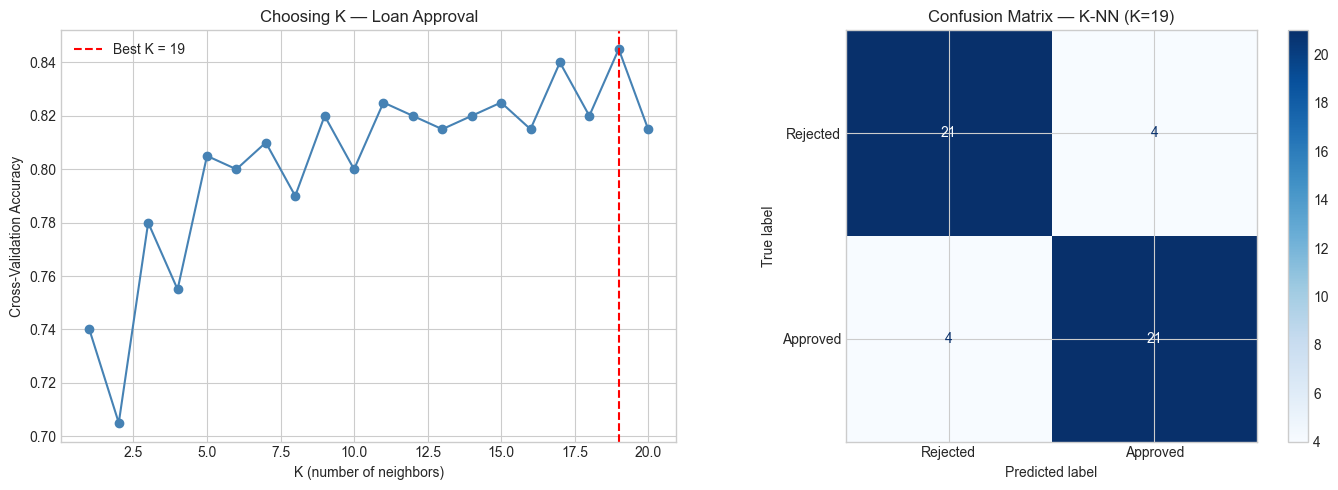

In [17]:
# Step 7) Visualization — K selection + confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), cv_scores, marker='o', color='steelblue')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
axes[0].set_xlabel('K (number of neighbors)')
axes[0].set_ylabel('Cross-Validation Accuracy')
axes[0].set_title('Choosing K — Loan Approval')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'Confusion Matrix — K-NN (K={best_k})')

plt.tight_layout()
plt.show()

## Example 2 — Cell 8: Evaluation

Full classification report with Accuracy, Precision, Recall, and F1.

**What this cell does:** Computes and displays evaluation metrics.

In [18]:
# Step 8) Evaluation

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Approved, fraction actually approved',
        'Of actual Approved, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))

print('\nDetailed classification report:')
print(classification_report(y_test, y_pred_test, target_names=['Rejected (0)', 'Approved (1)']))

print(f'\nExample 2 Test Accuracy = {acc:.4f}')

,Metric,Value,Description
0,Accuracy,0.84,Fraction of correct predictions
1,Precision,0.84,"Of predicted Approved, fraction actually approved"
2,Recall,0.84,"Of actual Approved, fraction correctly predicted"
3,F1 Score,0.84,Balance between Precision and Recall



Detailed classification report:
              precision    recall  f1-score   support

Rejected (0)       0.84      0.84      0.84        25
Approved (1)       0.84      0.84      0.84        25

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50


Example 2 Test Accuracy = 0.8400


## Why does K-NN work for Loan Approval?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Multi-feature distance** | Credit, income, loan, and employment define "similar" applicants |
| 2 | **No linear assumption** | Approval rules may be non-linear — K-NN adapts locally |
| 3 | **Scaling critical** | Income (~80k) vs YearsEmployed (~10) — must scale before distance |
| 4 | **K tuning** | Cross-validation picks K that generalizes on 4D feature space |
| 5 | **Balanced classes** | 50/50 split — accuracy is a fair metric |

> **Compare:** K-NN vs Logistic Regression on the same loan data — similar accuracy, different decision logic.

## Understanding Classification Metrics — Example 2

| Scenario | Focus Metric |
|----------|--------------|
| **False approval costly** | **Precision** |
| **False rejection costly** | **Recall** |
| **Balanced** | **Accuracy** or **F1** |

> K-NN in **high dimensions** (many features) can struggle (curse of dimensionality) — 4 features is manageable.